In [3]:
#importing the Libraries 
from imports import *

In [4]:
# Reading the dataset using pandas library...
df=pd.read_csv(r"C:\Users\suman\Downloads\income_data.csv")
df.head()

,Unnamed: 0,income,happiness
0,1,3.862647,2.314489
1,2,4.979381,3.433490
2,3,4.923957,4.599373
3,4,3.214372,2.791114
4,5,7.196409,5.596398


In [5]:
#checking the shape of the dataframe...
df.shape

(498, 3)

In [6]:
#checking the dataset information...
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  498 non-null    int64  
 1   income      498 non-null    float64
 2   happiness   498 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [7]:
#checking the count,mean,std,min,max and other statistical values of the dataset...
df.describe()

,Unnamed: 0,income,happiness
count,498.000000,498.000000,498.000000
mean,249.500000,4.466902,3.392859
std,143.904482,1.737527,1.432813
min,1.000000,1.506275,0.266044
25%,125.250000,3.006256,2.265864
50%,249.500000,4.423710,3.472536
75%,373.750000,5.991913,4.502621
max,498.000000,7.481521,6.863388


In [8]:
#checking the duplicate values in the dataset...
df.duplicated(keep='first').sum()

np.int64(0)

In [9]:
#nunique will shows the count of unique names of variables in the dataset...
df.nunique()

Unnamed: 0    498
income        498
happiness     498
dtype: int64

In [10]:
# Sorting the null values in the dataset in descending order...
df.isnull().sum().sort_values(ascending=False)

Unnamed: 0    0
income        0
happiness     0
dtype: int64

In [11]:
# Checking the Numeric columns in the dataset...
numeric_features = df.select_dtypes(include=[np.number])
numeric_features.columns

Index(['Unnamed: 0', 'income', 'happiness'], dtype='object')

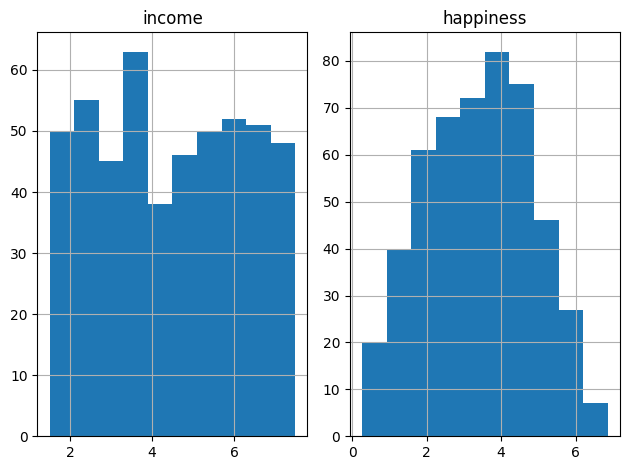

In [12]:
#Applying univariate analysis on the dataset...
df[['income','happiness']].hist()
plt.tight_layout()
plt.show()

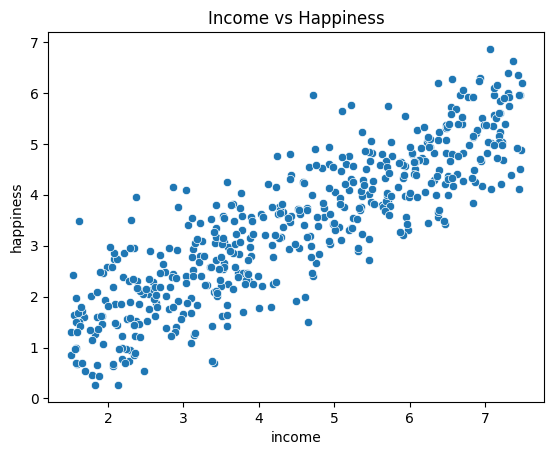

In [13]:
# Applying Bivariate Analysis on the dataset...
sns.scatterplot(x='income', y='happiness', data=df)
plt.title('Income vs Happiness')
plt.show()

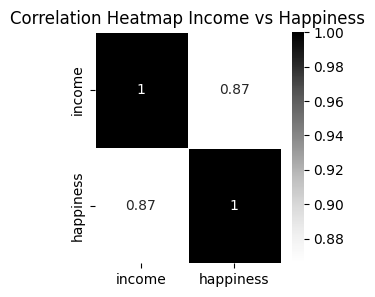

In [14]:
plt.figure(figsize=(3,3))
sns.heatmap(df[['income', 'happiness']].corr(), annot=True, cmap='Greys', linewidths=0.5)
plt.title('Correlation Heatmap Income vs Happiness')    
plt.show()

In [15]:
#income is the independent variable and happiness is the dependent variable... 
X = df[['income']]
y = df['happiness']
#Splitting the dataset into training and testing sets with a test size of 30% and a random state of 1 for reproducibility...
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# printing the shape of the training and testing sets...
print("Shape of  X training set:", X_train.shape)
print("Shape of  X testing set:", X_test.shape)        
print("Shape of y training set:", y_train.shape)
print("Shape of y testing set:", y_test.shape)

Shape of  X training set: (348, 1)
Shape of  X testing set: (150, 1)
Shape of y training set: (348,)
Shape of y testing set: (150,)


In [16]:
X_train_sm = sm.add_constant(X_train)
linreg = sm.OLS(y_train, X_train_sm).fit()
print(linreg.summary())

                            OLS Regression Results                            
Dep. Variable:              happiness   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     1020.
Date:                Wed, 17 Jun 2026   Prob (F-statistic):          3.14e-105
Time:                        10:33:41   Log-Likelihood:                -380.20
No. Observations:                 348   AIC:                             764.4
Df Residuals:                     346   BIC:                             772.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1585      0.108      1.468      0.1

In [17]:
X_test_sm = sm.add_constant(X_test)
y_pred = linreg.predict(X_test_sm)

In [18]:
# Compute accuracy measures on the test set
linreg_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
linreg_mae = mean_absolute_error(y_test, y_pred)
linreg_rsquared = linreg.rsquared

# calculate Adjusted R-Squared using rsquared_adj
linreg_rsquared_adj = linreg.rsquared_adj 
linreg_rsquared_test = r2_score(y_test, y_pred)

print("RMSE (test):", linreg_rmse)
print("MAE (test):", linreg_mae)
print("R-squared (train):", linreg_rsquared)
print("Adjusted R-squared (train):", linreg_rsquared_adj)
print("R-squared (test):", linreg_rsquared_test)

RMSE (test): 0.7059328995568673
MAE (test): 0.5588237111078116
R-squared (train): 0.7467917792621142
Adjusted R-squared (train): 0.7460599635952416
R-squared (test): 0.7545536758629199


In [19]:
# create a list of column names
cols = ['Model', 'RMSE','MAE', 'R-Squared', 'Adj. R-Squared']
# create an empty DataFrame with the specified column names
result_tabulation = pd.DataFrame(columns = cols)

# compile the required information
linreg_metrics = pd.Series({'Model': "Linear Regression using OLS",
                     'RMSE':linreg_rmse,
                     'MAE': linreg_mae,
                     'R-Squared': linreg_rsquared,
                     'Adj. R-Squared': linreg_rsquared_adj     
                   })

result_tabulation = result_tabulation._append(linreg_metrics, ignore_index = True)

# print the result table
result_tabulation


,Model,RMSE,MAE,R-Squared,Adj. R-Squared
0,Linear Regression using OLS,0.705933,0.558824,0.746792,0.74606


In [20]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge

# Use K-fold cross-validation to check coefficient stability
kf = KFold(n_splits=10, shuffle=True, random_state=1)
coef_values = []
for train_idx, test_idx in kf.split(X):
    X_train_cv = X.iloc[train_idx] 
    y_train_cv = y.iloc[train_idx] 
    X_train_cv_sm = sm.add_constant(X_train_cv)
    cv_model = sm.OLS(y_train_cv, X_train_cv_sm).fit()
    coef_values.append(cv_model.params['income'])

print('CV coefficient mean:', np.mean(coef_values))
print('CV coefficient std dev:', np.std(coef_values, ddof=1))
print('CV coefficient min/max:', min(coef_values), max(coef_values))

# Use Ridge to gently shrink the coefficient and reduce sensitivity
ridge_model = Ridge(alpha=1.0, random_state=1)
ridge_model.fit(X_train, y_train)
print('Ridge coefficient:', ridge_model.coef_[0])
print('Ridge intercept:', ridge_model.intercept_)


CV coefficient mean: 0.7138417236246232
CV coefficient std dev: 0.006456736387183769
CV coefficient min/max: 0.7065129695533652 0.726110037625451
Ridge coefficient: 0.7217364954832315
Ridge intercept: 0.1616347017677624


In [21]:
# Mean Absolute Percentage Error (MAPE) - % error
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE: {mape:.4f}")

# Root Mean Squared Log Error (for non-negative values)
from sklearn.metrics import mean_squared_log_error
rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))

MAPE: 0.2534


In [38]:
# Comprehensive Model Performance Summary
print("=" * 60)
print("MODEL PERFORMANCE SUMMARY - REGRESSION METRICS")
print("=" * 60)
print(f"\n📊 EXPLAINED VARIANCE:")
print(f"   R-Squared (R²):          {linreg_rsquared_test:.4f} → Model explains {linreg_rsquared_test*100:.2f}% of variance")
print(f"\n📈 PREDICTION ERROR:")
print(f"   RMSE (Root Mean Squared Error): {linreg_rmse:.4f}")
print(f"   MAE (Mean Absolute Error):      {linreg_mae:.4f}")
print(f"   MAPE (Mean Absolute % Error):   {mape:.4f} → Average {mape*100:.2f}% error")
print(f"\n✅ INTERPRETATION:")
if linreg_rsquared_test >= 0.8:
    print(f"   Excellent Model! R² = {linreg_rsquared_test:.2%}")
elif linreg_rsquared_test >= 0.6:
    print(f"   Good Model! R² = {linreg_rsquared_test:.2%} - Model is performing well")
elif linreg_rsquared_test >= 0.4:
    print(f"   Fair Model. R² = {linreg_rsquared_test:.2%} - Consider improvements")
else:
    print(f"   Poor Model. R² = {linreg_rsquared_test:.2%} - Model needs improvement")
print("=" * 60)


MODEL PERFORMANCE SUMMARY - REGRESSION METRICS

📊 EXPLAINED VARIANCE:
   R-Squared (R²):          0.7546 → Model explains 75.46% of variance

📈 PREDICTION ERROR:
   RMSE (Root Mean Squared Error): 0.7059
   MAE (Mean Absolute Error):      0.5588
   MAPE (Mean Absolute % Error):   0.2534 → Average 25.34% error

✅ INTERPRETATION:
   Good Model! R² = 75.46% - Model is performing well


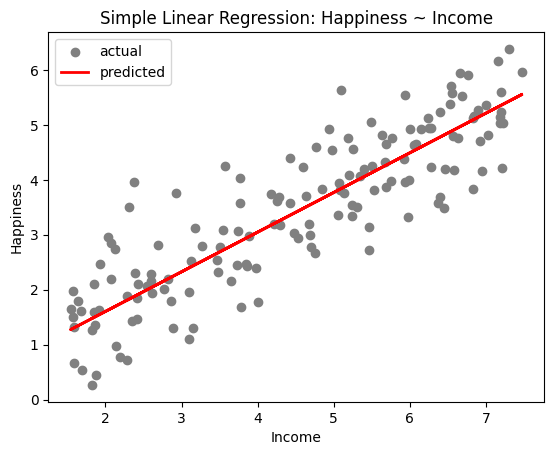

In [23]:
plt.scatter(X_test, y_test, color='grey', label='actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='predicted')
plt.xlabel('Income')
plt.ylabel('Happiness')
plt.title('Simple Linear Regression: Happiness ~ Income')
plt.legend()
plt.show()

#### Conclusion
* The model explains about 75% of the variance in happiness from income
* The test set performance is strong and consistent ... !